# NCypher - reproduce the analysis

**Decode the non-coding.** This notebook reproduces NCypher's headline results and figures from the
scored variant tables, end to end, on a laptop (CPU only).

**Honest scope.** The heavy step - scoring variants with the Corces developing-brain **ChromBPNet**
(predicted chromatin accessibility) - runs on GPU via Modal (`modal/score_variants.py`) and is
*documented, not re-run here*. Its output, `data/dmg/sweep_result.tsv`, is the reproducible starting
point. From there everything below (calibration, the caQTL validation, the K27M super-enhancer
finding, the motif figure) reproduces with `requirements.txt` alone.

One command: `jupyter nbconvert --to notebook --execute notebooks/reproduce.ipynb`.

## Provenance (pinned)
- **Engine:** Corces *et al.* developing-brain ChromBPNet, context **c15 (fetal OPC / progenitor)** (accession in `CLAUDE.md` / `docs/reference`).
- **Cohort:** OpenPedCan v15, 158 DMG patients, ~1.1M non-coding SNVs.
- **Constraint:** Zoonomia **phyloP** (241-mammal).
- **caQTLs:** Liang progenitor / neuron + PsychENCODE (mismatched control).
- **Super-enhancers:** Nagaraja *et al.* 2017 (DIPG), Table S4, hg19 -> hg38 liftOver.
- Genome hg38. Seeds fixed (permutation `rng(0)`, 1000 draws).

In [1]:
import os, sys, subprocess
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Image, display

# run from the repo root wherever the notebook launched
REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
os.chdir(REPO); sys.path.insert(0, str(REPO / "src"))
np.random.seed(0)

def run(script, timeout=900):
    "Drive a real pipeline script with PYTHONPATH=src and echo its tail."
    r = subprocess.run([sys.executable, f"scripts/{script}"], cwd=REPO,
                       env={**os.environ, "PYTHONPATH": "src"},
                       capture_output=True, text=True, timeout=timeout)
    print(r.stdout[-4000:] or "(no stdout)")
    if r.returncode:
        print("-- STDERR --\n", r.stderr[-2500:])
    return r.returncode

need = ["data/dmg/sweep_result.tsv", "data/mpra/DataS2-Variant-library-ratios.xlsx",
        "data/mpra/mpra_validation.result.tsv", "data/dmg/enhancers/hg19ToHg38.over.chain.gz"]
missing = [f for f in need if not (REPO / f).exists()]
print("repo   :", REPO)
print("python :", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__)
print("inputs :", "ALL present" if not missing else f"MISSING {missing} (data/ is fetched not committed; see docs/data/sources.md)")

repo   : /Users/faith/Desktop/NCypher
python : 3.10.16 | numpy 2.2.6 | pandas 2.3.3
inputs : ALL present


## Step 1 - the engine and its calibration

`sweep_result.tsv` is the ChromBPNet-scored universe: every cohort somatic non-coding SNV that lands
in a Corces c15 OPC-accessible peak. The chromatin-impact threshold is **calibrated** (the 99th
percentile of the null), not the meaningless absolute 0.5. Convergence requires chromatin **and**
constraint to agree; the honest headline is a **negative**: no single recurrent non-coding driver.

In [2]:
sw   = pd.read_csv("data/dmg/sweep_result.tsv", sep="\t")
hi   = sw["high_impact"].fillna(0).astype(bool)
cut  = sw.loc[hi, "abs_logfc"].min()          # the engine's calibrated high-impact cutoff (99th pctile of the null)
conv = int(sw["converged_2ax"].fillna(0).astype(bool).sum())
print(f"OPC-regulatory variants scored : {len(sw):,}")
print(f"calibrated high-impact cutoff  : |log2FC| >= {cut:.3f}  (99th percentile of the null, not the meaningless 0.5)")
print(f"chromatin high-impact variants : {int(hi.sum())}")
print(f"converged (chromatin + constraint): {conv}")
print(f"recurrent non-coding driver    : 0  ->  honest negative")
sw.head(4)

OPC-regulatory variants scored : 10,869
calibrated high-impact cutoff  : |log2FC| >= 0.162  (99th percentile of the null, not the meaningless 0.5)
chromatin high-impact variants : 753
converged (chromatin + constraint): 164
recurrent non-coding driver    : 0  ->  honest negative


,key,gene,cls,n_patients,logfc,abs_logfc,jsd,phylop,constrained,high_impact,promote,confidence,impact_pctile,converged_2ax
0,chr22-33000876-C-T,SYN3,Intron,1,-1.244303,1.244303,0.379334,8.583,True,True,True,medium,1.0,True
1,chr1-16621200-C-A,LOC105376794,RNA,1,-1.165935,1.165935,0.457662,3.711,True,True,True,medium,1.0,True
2,chr13-98333680-C-G,FARP1,Intron,1,-1.163515,1.163515,0.037511,8.639,True,True,True,medium,1.0,True
3,chr8-130749833-G-T,ENSR00000333478,IGR,1,-1.072691,1.072691,0.320596,8.273,True,True,True,medium,1.0,True


## Step 2 - the chromatin axis, validated against caQTLs (the headline)

caQTLs (allelic-imbalance accessibility QTLs) are the **native** ground truth for a chromatin-
accessibility model - unlike the MPRA DAVs, which measure reporter *activity* (a different modality,
an honest negative below). The c15 model is a fetal OPC/progenitor context, so the honest prediction
is that it best recovers **progenitor** caQTLs. First the transparent headline inline, then the full
context panel + bootstrap CIs via the real scripts.

In [3]:
# transparent headline: recover progenitor caQTLs by predicted |log2FC|
from nc_score.validate import ranking_report
res = pd.read_csv("data/mpra/mpra_validation.result.tsv", sep="\t")
s2  = pd.read_excel("data/mpra/DataS2-Variant-library-ratios.xlsx", sheet_name="Primary")
res = res.merge(s2[["rsid", "cqtl_liang_progenitor"]], on="rsid", how="left")
lab = (res["cqtl_liang_progenitor"] == 1).astype(int).values
rr  = ranking_report(lab, res["pred_abs"].values)
print(f"Progenitor caQTL (matched context): n_pos={int(lab.sum())}  "
      f"AUROC={rr.auroc:.3f}  {rr.auprc_fold_over_baseline:.1f}x baseline")

Progenitor caQTL (matched context): n_pos=45  AUROC=0.689  7.5x baseline


In [4]:
run("validate_caqtl.py"); run("bootstrap_caqtl.py")
print("\ncontext panel:"); display(pd.read_csv("data/mpra/caqtl_validation.tsv", sep="\t"))
print("bootstrap 95% CIs:"); display(pd.read_csv("data/mpra/caqtl_bootstrap_ci.tsv", sep="\t"))

Progenitor caQTL: n=45 AUPRC=0.042 (7.5x) AUROC=0.689 p=5.8e-06
Neuron caQTL: n=29 AUPRC=0.017 (4.8x) AUROC=0.635 p=0.0058
Any caQTL: n=93 AUPRC=0.042 (3.7x) AUROC=0.616 p=5.8e-05
PsychENCODE caQTL: n=23 AUPRC=0.003 (1.0x) AUROC=0.449 p=0.8

wrote data/figures/caqtl_context_specificity.png and data/mpra/caqtl_validation.tsv



progenitor (matched)       n= 45  AUROC 0.689 [0.592, 0.777]  AUPRC 7.5x [3.2, 20.3]
neuron                     n= 29  AUROC 0.635 [0.525, 0.735]  AUPRC 4.8x [1.5, 20.4]
any                        n= 93  AUROC 0.616 [0.549, 0.679]  AUPRC 3.7x [2.1, 7.6]
PsychENCODE (mismatched)   n= 23  AUROC 0.449 [0.324, 0.578]  AUPRC 1.0x [0.8, 2.1]

context-specificity gap (progenitor AUROC - mismatched AUROC):
  point +0.240  95% CI [+0.081, +0.394]  P(gap>0)=0.994  (excludes 0)

wrote data/mpra/caqtl_bootstrap_ci.tsv and caqtl_bootstrap_gap.txt


context panel:


,set,n_pos,auprc,fold,auroc,mwu_p
0,Progenitor caQTL\n(matched context),45,0.041901,7.458373,0.689193,0.000006
1,Neuron caQTL,29,0.017249,4.764186,0.635406,0.005848
2,Any caQTL,93,0.042413,3.652974,0.616123,0.000058
3,PsychENCODE caQTL\n(mismatched),23,0.002874,1.000760,0.448996,0.801257


bootstrap 95% CIs:


,context,n_pos,auroc,auroc_lo,auroc_hi,auprc_fold,fold_lo,fold_hi,n_valid_boot
0,progenitor (matched),45,0.689,0.592,0.777,7.5,3.2,20.3,1000
1,neuron,29,0.635,0.525,0.735,4.8,1.5,20.4,1000
2,any,93,0.616,0.549,0.679,3.7,2.1,7.6,1000
3,PsychENCODE (mismatched),23,0.449,0.324,0.578,1.0,0.8,2.1,1000


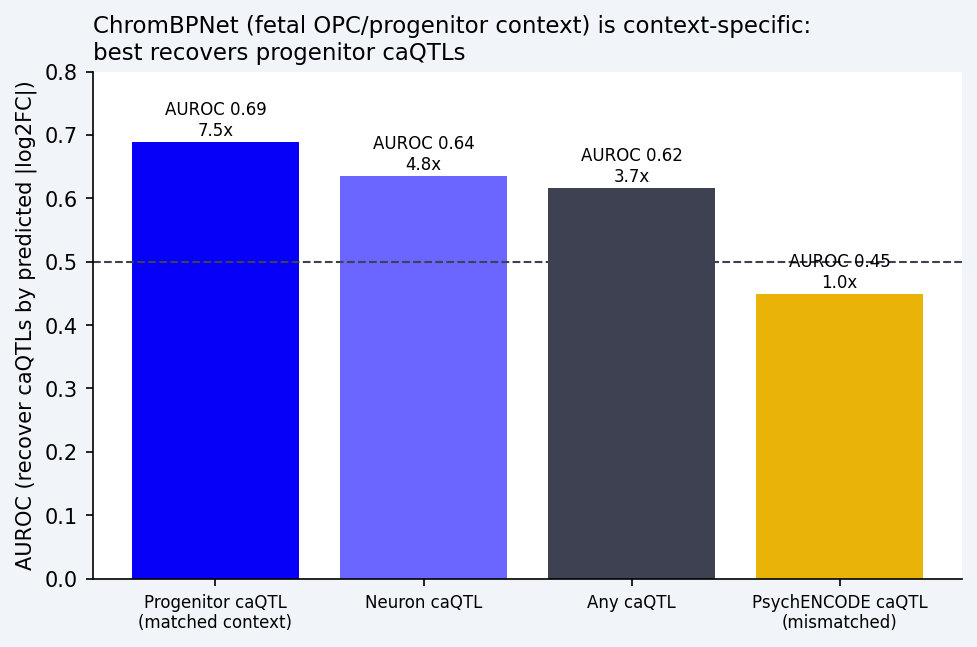

In [5]:
Image(filename="data/figures/caqtl_context_specificity.png", embed=True)

## Step 3 - the flagship: the K27M super-enhancer finding

Do the cohort's OPC-regulatory somatic variants inside the DIPG super-enhancer addiction (Nagaraja
Table S4) carry more of the functional / constrained signal? Both arms are OPC-accessible, so
accessibility is controlled; super-enhancer membership is the only contrast. The signal survives a
**class-matched** and a **GC-matched** permutation (both re-run below), and it is an honest two-sided
result: the variants do **not** drive the super-enhancers (chromatin null), but the super-enhancers
sit on **more constrained** OPC sequence.

In [6]:
run("k27m_se_analysis.py"); run("k27m_se_constraint_control.py")
sl = pd.read_csv("data/dmg/enhancers/converged_in_dipg_se.tsv", sep="\t")
print(f"\nconverged variants inside DIPG super-enhancers: {len(sl)}  (NPAS3 the lead)")
sl.head(12)

super-enhancers lifted hg19->hg38: 4726 (dropped 13 unmappable), 4 lines, 23 chroms
union SE footprint: 169.3 Mb over 3100 merged intervals

OPC-regulatory variants: 10869 total, 1946 in DIPG SEs, 8923 outside

--- IN-SE vs OUT-SE (both are OPC-accessible; SE membership is the only contrast) ---
  converged (2-axis)    : in-SE 31/1946 (1.6%)  vs  out 133/8923 (1.5%)  fold 1.07  Fisher p=0.4
  chromatin high-impact : in-SE 144/1946 (7.4%)  vs  out 609/8923 (6.8%)  fold 1.08  Fisher p=0.195
  phyloP-constrained    : in-SE 330/1946 (17.0%)  vs  out 1253/8923 (14.0%)  fold 1.21  Fisher p=0.000641
  phyloP                : in-SE median 0.283  vs out 0.185  MWU p=0.00261
  |log2FC| chromatin    : in-SE median 0.025  vs out 0.025  MWU p=0.0896

Converged variants inside DIPG super-enhancers: 31
                key            gene     logfc  phylop confidence
 chr2-176638323-C-A       LINC01117 -0.255973   8.825     medium
 chr22-37968014-G-A          POLR2F -0.702443   8.700     medium
 chr20

n in-SE=1946  out-SE=8907  in-SE median phyloP=0.283  out=0.185

[1] class x GC matched permutation: in-SE 0.283 vs null 0.154 [0.128, 0.183]  p=0  (SURVIVES class+GC control)
[2] bootstrap median-phyloP difference (in-SE minus out-SE): +0.094  95% CI [+0.029, +0.162]  (excludes 0)
[3] honest decomposition (constrained fraction, in-SE vs out-SE):
    genic (intron+UTR)  : in-SE 17.5% vs out 14.4%  (n=1694/7036)
    intergenic (IGR)    : in-SE 11.6% vs out 12.1%  (n=189/1564)

wrote data/dmg/enhancers/constraint_control_result.txt


converged variants inside DIPG super-enhancers: 31  (NPAS3 the lead)


,key,gene,logfc,phylop,confidence,chrom,pos
0,chr2-176638323-C-A,LINC01117,-0.255973,8.825,medium,chr2,176638323
1,chr22-37968014-G-A,POLR2F,-0.702443,8.700,medium,chr22,37968014
2,chr20-32528285-C-T,NOL4L,-0.185237,7.024,medium,chr20,32528285
3,chr19-13151895-C-G,IER2,-0.175681,6.945,medium,chr19,13151895
4,chr7-37007541-C-G,ELMO1,-0.315091,5.977,medium,chr7,37007541
5,chr11-72631936-C-A,PDE2A,-0.311368,5.913,medium,chr11,72631936
6,chr18-56067406-G-T,LINC01905,0.211220,5.897,medium,chr18,56067406
7,chr3-172153482-C-G,FNDC3B,-0.259401,5.787,medium,chr3,172153482
8,chr11-36196158-G-A,LDLRAD3,-0.259515,5.684,medium,chr11,36196158
9,chr1-232620638-C-T,SIPA1L2,-0.220158,5.016,medium,chr1,232620638


## Step 4 - the mechanism (motif readout)

The honest motif figure: of the super-enhancer-resident hits, only a minority disrupt a clear generic
motif, coherent with the chromatin null. We show what the model sees, not a forced story.

wrote data/figures/se_motif_readout.png  (4 SE-resident readouts, real DeepSHAP)



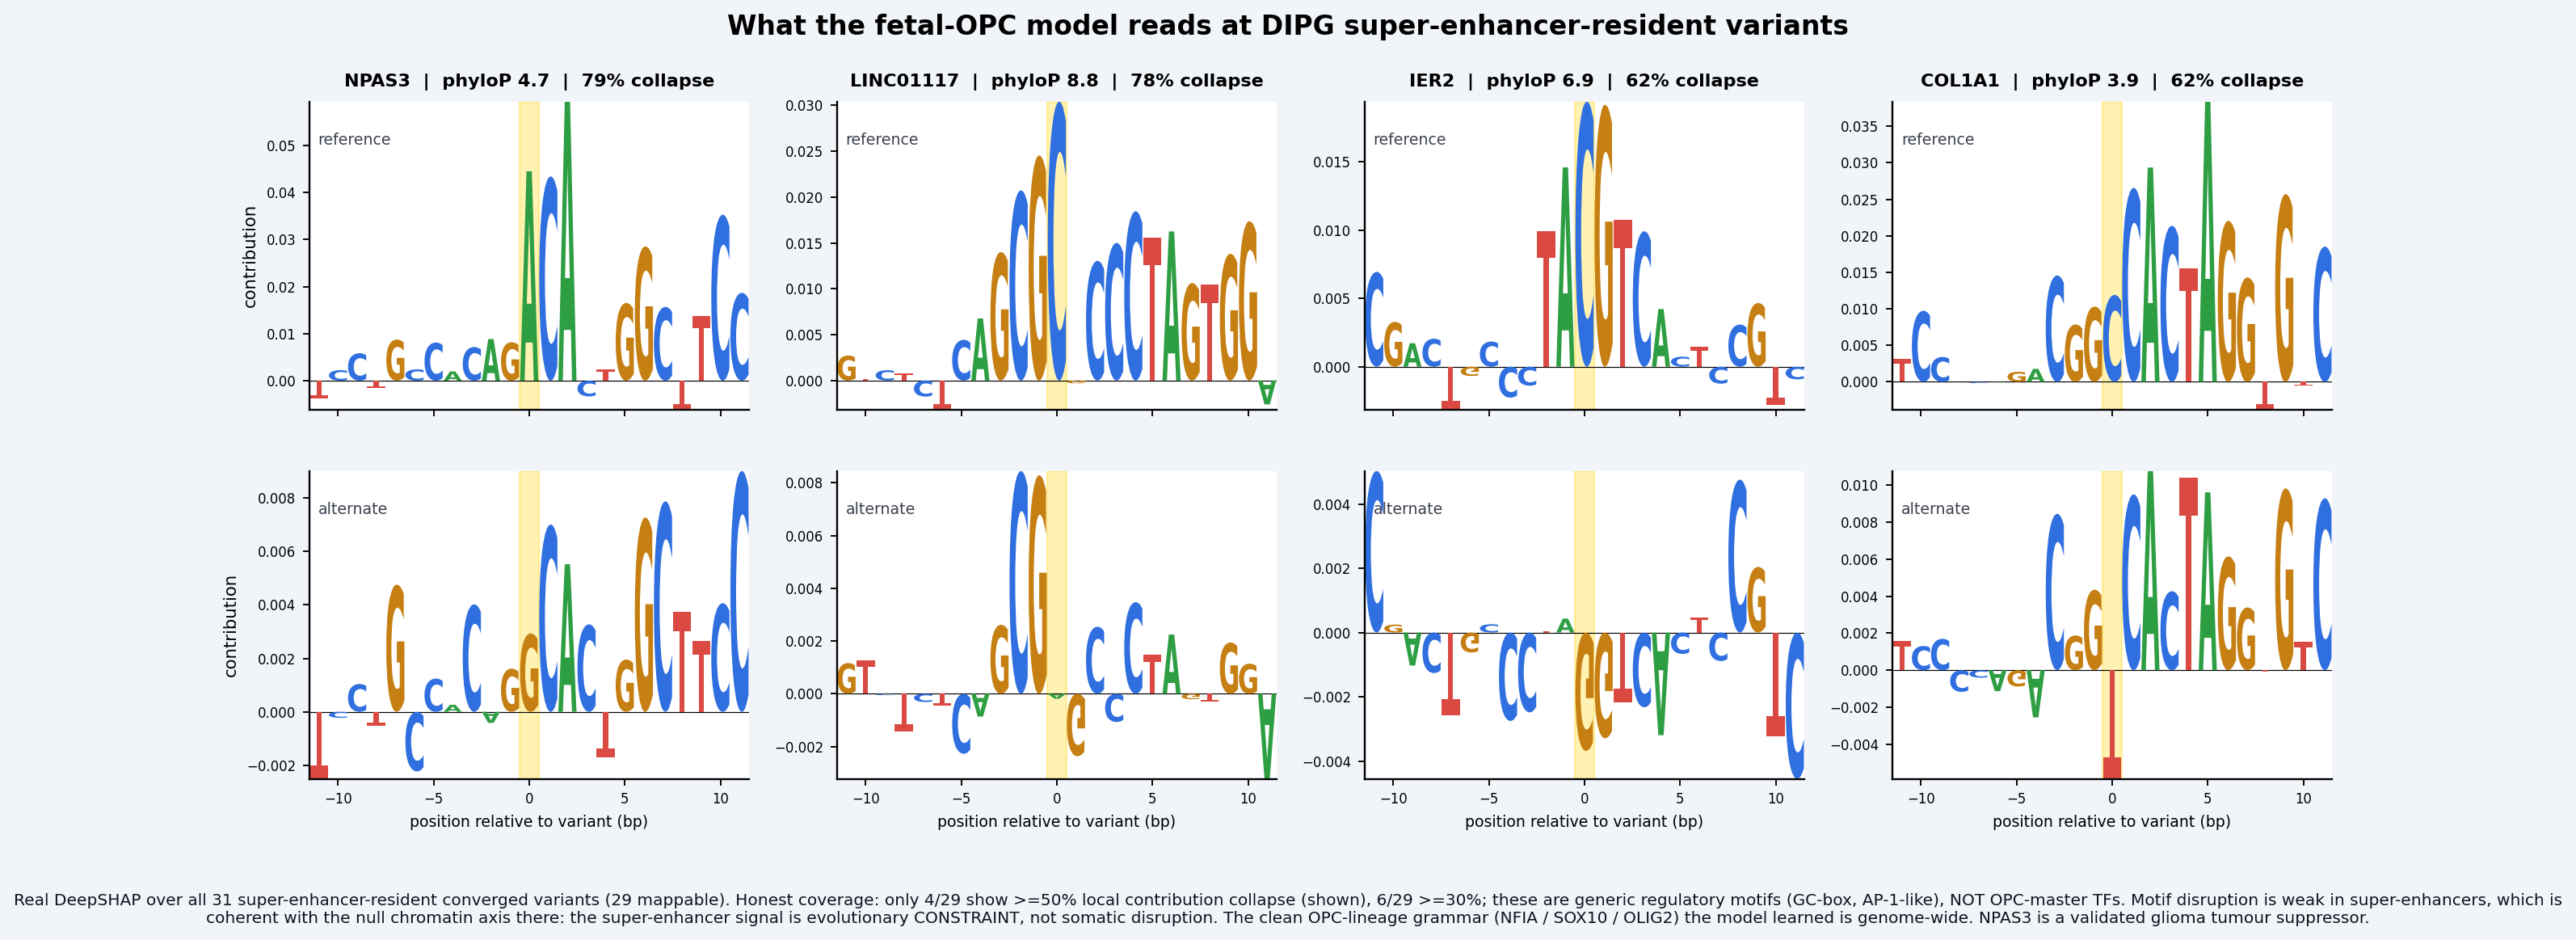

In [7]:
run("render_se_motif_figure.py")
Image(filename="data/figures/se_motif_readout.png", embed=True)

## Honest limitations
- **The MPRA DAVs are a negative** (AUPRC ~ chance): ChromBPNet predicts chromatin *accessibility*, not
  reporter *activity*. caQTLs are the correct ground truth; we report the honest negative rather than hide it.
- **Enrichment is not selection.** The super-enhancer constraint signal is hypothesis-generating; low DMG
  non-coding burden caps power. The matched permutations guard the claim, they do not prove causation.
- **Out of domain:** anything outside the fetal-OPC context (e.g. breast) is flagged low-confidence by design.

## Reproducibility
- Environment: `pip install -r requirements.txt` (Python 3.10). GPU / ChromBPNet upstream: `modal/score_variants.py`.
- Seeds fixed (permutation `rng(0)`, 1000 draws). Figures written to `data/figures/`.
- The CI **reproducibility gate** re-runs the caQTL validation on every push and has Claude verify the
  headline **AUROC 0.69 / 7.5x** still reproduces and still matches the README.